In [ ]:
import torch

print("GPU available:", torch.cuda.is_available())
print("Device name:", torch.cuda.get_device_name(0))


GPU available: True
Device name: Tesla T4


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from tqdm import tqdm
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [ ]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])


trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform
)

testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform
)

trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=32, shuffle=True, num_workers=2
)

testloader = torch.utils.data.DataLoader(
    testset, batch_size=32, shuffle=False, num_workers=2
)

print("Dataset ready ✅")


100%|██████████| 170M/170M [00:03<00:00, 43.1MB/s]


Dataset ready ✅


In [ ]:
def train_model(model, trainloader, criterion, optimizer, epochs):

    model.to(device)
    start_time = time.time()

    for epoch in range(epochs):

        model.train()

        running_loss = 0
        correct = 0
        total = 0

        loop = tqdm(enumerate(trainloader), total=len(trainloader),
                    desc=f"Epoch [{epoch+1}/{epochs}]")

        for i, (images, labels) in loop:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            # ✅ CORRECT LOSS DISPLAY
            loop.set_postfix(
                loss=running_loss/(i+1),
                acc=100*correct/total
            )

        print(f"Epoch {epoch+1} Training Accuracy: {100*correct/total:.2f}%")

    print("Training Time:", time.time() - start_time)


In [ ]:
def test_model(model, testloader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in testloader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print("Test Accuracy:", 100 * correct / total)


VGG16

In [ ]:
import torch.nn as nn

class VGG16(nn.Module):
    def __init__(self, num_classes=10):
        super(VGG16, self).__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(256, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(512, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.AdaptiveAvgPool2d((7, 7))
        )

        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 1024),
            nn.ReLU(True),
            nn.Dropout(),

            nn.Linear(1024, 512),
            nn.ReLU(True),
            nn.Dropout(),

            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x


In [ ]:
model = VGG16()

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0005   # 🔥 Best for VGG + BN
)

train_model(model, trainloader, criterion, optimizer, epochs=10)
test_model(model, testloader)


Epoch [1/10]: 100%|██████████| 1563/1563 [04:53<00:00,  5.32it/s, acc=23.1, loss=2.01]

Epoch 1 Training Accuracy: 23.07%



Epoch [2/10]: 100%|██████████| 1563/1563 [04:52<00:00,  5.34it/s, acc=38.4, loss=1.63]

Epoch 2 Training Accuracy: 38.35%



Epoch [3/10]: 100%|██████████| 1563/1563 [04:53<00:00,  5.32it/s, acc=52.2, loss=1.33]

...


Epoch [9/10]: 100%|██████████| 1563/1563 [04:54<00:00,  5.32it/s, acc=83.1, loss=0.521]

Epoch 9 Training Accuracy: 83.12%



Epoch [10/10]: 100%|██████████| 1563/1563 [04:54<00:00,  5.31it/s, acc=85.5, loss=0.446]

Epoch 10 Training Accuracy: 85.45%
Training Time: 2939.21745800972


Test Accuracy: 81.26


ResNet-50

In [ ]:
import torch
import torch.nn as nn

# 🔥 Residual Block (Bottleneck for ResNet-50)
class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, in_channels, out_channels, stride=1):
        super(Bottleneck, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, 3,
                               stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.conv3 = nn.Conv2d(out_channels,
                               out_channels * self.expansion,
                               1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels * self.expansion)

        self.relu = nn.ReLU(inplace=True)

        self.downsample = None
        if stride != 1 or in_channels != out_channels * self.expansion:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels,
                          out_channels * self.expansion,
                          1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * self.expansion)
            )

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out


# 🔥 ResNet-50 Model
class ResNet50(nn.Module):
    def __init__(self, num_classes=10):
        super(ResNet50, self).__init__()

        self.in_channels = 64

        self.conv1 = nn.Conv2d(3, 64, 7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(3, stride=2, padding=1)

        # Layers (ResNet-50 configuration)
        self.layer1 = self._make_layer(64, 3)
        self.layer2 = self._make_layer(128, 4, stride=2)
        self.layer3 = self._make_layer(256, 6, stride=2)
        self.layer4 = self._make_layer(512, 3, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * 4, num_classes)

    def _make_layer(self, out_channels, blocks, stride=1):
        layers = []

        layers.append(Bottleneck(self.in_channels,
                                 out_channels, stride))

        self.in_channels = out_channels * 4

        for _ in range(1, blocks):
            layers.append(Bottleneck(self.in_channels,
                                     out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x


In [ ]:
model = ResNet50()

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

train_model(model, trainloader, criterion, optimizer, epochs=10)
test_model(model, testloader)


Epoch [1/10]: 100%|██████████| 1563/1563 [03:10<00:00,  8.21it/s, acc=39.9, loss=1.66]

Epoch 1 Training Accuracy: 39.87%



Epoch [2/10]: 100%|██████████| 1563/1563 [03:09<00:00,  8.23it/s, acc=58.4, loss=1.17]

Epoch 2 Training Accuracy: 58.39%



Epoch [3/10]: 100%|██████████| 1563/1563 [03:09<00:00,  8.24it/s, acc=66.6, loss=0.951]

...


Epoch [9/10]: 100%|██████████| 1563/1563 [03:09<00:00,  8.24it/s, acc=88.6, loss=0.325]

Epoch 9 Training Accuracy: 88.58%



Epoch [10/10]: 100%|██████████| 1563/1563 [03:09<00:00,  8.23it/s, acc=91.1, loss=0.254]

Epoch 10 Training Accuracy: 91.10%
Training Time: 1899.8555040359497


Test Accuracy: 81.79


REsnet-100

In [ ]:
class ResNet101(nn.Module):
    def __init__(self, num_classes=10):
        super(ResNet101, self).__init__()

        self.in_channels = 64

        self.conv1 = nn.Conv2d(3, 64, 7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(3, stride=2, padding=1)

        # ⭐ CHANGED BLOCK COUNTS
        self.layer1 = self._make_layer(64, 3)
        self.layer2 = self._make_layer(128, 4, stride=2)
        self.layer3 = self._make_layer(256, 23, stride=2)  # 🔥 BIG CHANGE
        self.layer4 = self._make_layer(512, 3, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * 4, num_classes)

    def _make_layer(self, out_channels, blocks, stride=1):
        layers = []

        layers.append(Bottleneck(self.in_channels,
                                 out_channels, stride))

        self.in_channels = out_channels * 4

        for _ in range(1, blocks):
            layers.append(Bottleneck(self.in_channels,
                                     out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x


In [ ]:
model = ResNet101()

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

train_model(model, trainloader, criterion, optimizer, epochs=10)
test_model(model, testloader)


Epoch [1/10]: 100%|██████████| 1563/1563 [05:10<00:00,  5.04it/s, acc=38.5, loss=1.69]

Epoch 1 Training Accuracy: 38.52%



Epoch [2/10]: 100%|██████████| 1563/1563 [05:09<00:00,  5.05it/s, acc=53.5, loss=1.29]

Epoch 2 Training Accuracy: 53.50%



Epoch [3/10]: 100%|██████████| 1563/1563 [05:09<00:00,  5.05it/s, acc=62.6, loss=1.05]

...


Epoch [9/10]: 100%|██████████| 1563/1563 [05:09<00:00,  5.05it/s, acc=87.9, loss=0.345]

Epoch 9 Training Accuracy: 87.86%



Epoch [10/10]: 100%|██████████| 1563/1563 [05:08<00:00,  5.06it/s, acc=90.5, loss=0.274]

Epoch 10 Training Accuracy: 90.51%
Training Time: 3093.776985168457


Test Accuracy: 80.48


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# 🔥 Squeeze-and-Excitation block
class SEBlock(nn.Module):
    def __init__(self, in_channels, reduction=4):
        super(SEBlock, self).__init__()
        self.fc1 = nn.Linear(in_channels, in_channels // reduction)
        self.fc2 = nn.Linear(in_channels // reduction, in_channels)

    def forward(self, x):
        b, c, _, _ = x.size()
        y = F.adaptive_avg_pool2d(x, 1).view(b, c)
        y = F.relu(self.fc1(y))
        y = torch.sigmoid(self.fc2(y)).view(b, c, 1, 1)
        return x * y


# 🔥 MBConv Block
class MBConv(nn.Module):
    def __init__(self, in_channels, out_channels, expand_ratio, stride):
        super(MBConv, self).__init__()

        hidden_dim = in_channels * expand_ratio

        self.use_residual = (stride == 1 and in_channels == out_channels)

        layers = []

        # Expansion
        if expand_ratio != 1:
            layers.append(nn.Conv2d(in_channels, hidden_dim, 1, bias=False))
            layers.append(nn.BatchNorm2d(hidden_dim))
            layers.append(nn.ReLU6(inplace=True))

        # Depthwise convolution
        layers.append(nn.Conv2d(hidden_dim, hidden_dim, 3,
                                stride=stride, padding=1,
                                groups=hidden_dim, bias=False))
        layers.append(nn.BatchNorm2d(hidden_dim))
        layers.append(nn.ReLU6(inplace=True))

        # Squeeze-Excitation
        layers.append(SEBlock(hidden_dim))

        # Projection
        layers.append(nn.Conv2d(hidden_dim, out_channels, 1, bias=False))
        layers.append(nn.BatchNorm2d(out_channels))

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        if self.use_residual:
            return x + self.block(x)
        else:
            return self.block(x)


# 🔥 EfficientNet-B0 Model
class EfficientNetB0(nn.Module):
    def __init__(self, num_classes=10):
        super(EfficientNetB0, self).__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU6(inplace=True)
        )

        self.blocks = nn.Sequential(

            MBConv(32, 16, expand_ratio=1, stride=1),
            MBConv(16, 24, expand_ratio=6, stride=2),
            MBConv(24, 24, expand_ratio=6, stride=1),

            MBConv(24, 40, expand_ratio=6, stride=2),
            MBConv(40, 40, expand_ratio=6, stride=1),

            MBConv(40, 80, expand_ratio=6, stride=2),
            MBConv(80, 80, expand_ratio=6, stride=1),
            MBConv(80, 80, expand_ratio=6, stride=1),

            MBConv(80, 112, expand_ratio=6, stride=1),
            MBConv(112, 112, expand_ratio=6, stride=1),

            MBConv(112, 192, expand_ratio=6, stride=2),
            MBConv(192, 192, expand_ratio=6, stride=1),
            MBConv(192, 192, expand_ratio=6, stride=1),

            MBConv(192, 320, expand_ratio=6, stride=1)
        )

        self.head = nn.Sequential(
            nn.Conv2d(320, 1280, 1, bias=False),
            nn.BatchNorm2d(1280),
            nn.ReLU6(inplace=True)
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(1280, num_classes)

    def forward(self, x):

        x = self.stem(x)
        x = self.blocks(x)
        x = self.head(x)

        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x


In [ ]:
model = EfficientNetB0()

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

train_model(model, trainloader, criterion, optimizer, epochs=10)
test_model(model, testloader)


Epoch [1/10]: 100%|██████████| 1563/1563 [01:36<00:00, 16.18it/s, acc=49.8, loss=1.37]

Epoch 1 Training Accuracy: 49.76%



Epoch [2/10]: 100%|██████████| 1563/1563 [01:36<00:00, 16.23it/s, acc=67.1, loss=0.931]

Epoch 2 Training Accuracy: 67.11%



Epoch [3/10]: 100%|██████████| 1563/1563 [01:38<00:00, 15.81it/s, acc=74.3, loss=0.743]

...


Epoch [9/10]: 100%|██████████| 1563/1563 [01:36<00:00, 16.21it/s, acc=88.4, loss=0.331]

Epoch 9 Training Accuracy: 88.43%



Epoch [10/10]: 100%|██████████| 1563/1563 [01:35<00:00, 16.30it/s, acc=89.5, loss=0.299]

Epoch 10 Training Accuracy: 89.55%
Training Time: 969.6568112373352


Test Accuracy: 83.6


InceptionV3

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class InceptionBlock(nn.Module):
    def __init__(self, in_channels, out1, red3, out3, red5, out5, pool_proj):
        super(InceptionBlock, self).__init__()

        # 1x1 branch
        self.branch1 = nn.Conv2d(in_channels, out1, kernel_size=1)

        # 1x1 -> 3x3 branch
        self.branch2 = nn.Sequential(
            nn.Conv2d(in_channels, red3, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(red3, out3, kernel_size=3, padding=1)
        )

        # 1x1 -> 5x5 branch
        self.branch3 = nn.Sequential(
            nn.Conv2d(in_channels, red5, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(red5, out5, kernel_size=5, padding=2)
        )

        # pooling branch
        self.branch4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            nn.Conv2d(in_channels, pool_proj, kernel_size=1)
        )

    def forward(self, x):

        b1 = self.branch1(x)
        b2 = self.branch2(x)
        b3 = self.branch3(x)
        b4 = self.branch4(x)

        return torch.cat([b1, b2, b3, b4], 1)


In [ ]:
class InceptionV3(nn.Module):
    def __init__(self, num_classes=10):
        super(InceptionV3, self).__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, 3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )

        # Inception blocks
        self.inception1 = InceptionBlock(128, 32, 32, 48, 8, 16, 16)
        self.inception2 = InceptionBlock(112, 64, 48, 64, 8, 16, 16)

        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(160, num_classes)

    def forward(self, x):

        x = self.stem(x)

        x = self.inception1(x)
        x = self.inception2(x)

        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x


In [ ]:
model = InceptionV3()

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

train_model(model, trainloader, criterion, optimizer, epochs=10)
test_model(model, testloader)


Epoch [1/10]: 100%|██████████| 1563/1563 [01:14<00:00, 21.09it/s, acc=32.6, loss=1.8]


Epoch 1 Training Accuracy: 32.65%


Epoch [2/10]: 100%|██████████| 1563/1563 [01:12<00:00, 21.50it/s, acc=47, loss=1.45]

Epoch 2 Training Accuracy: 47.03%



Epoch [3/10]: 100%|██████████| 1563/1563 [01:12<00:00, 21.70it/s, acc=52.7, loss=1.31]

...


Epoch [9/10]: 100%|██████████| 1563/1563 [01:12<00:00, 21.58it/s, acc=64.7, loss=0.991]

Epoch 9 Training Accuracy: 64.73%



Epoch [10/10]: 100%|██████████| 1563/1563 [01:12<00:00, 21.60it/s, acc=65.4, loss=0.966]

Epoch 10 Training Accuracy: 65.45%
Training Time: 727.1360151767731


Test Accuracy: 66.15


MobileNetV1

In [ ]:
import torch
import torch.nn as nn

class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(DepthwiseSeparableConv, self).__init__()

        self.depthwise = nn.Conv2d(
            in_channels, in_channels,
            kernel_size=3, stride=stride,
            padding=1, groups=in_channels, bias=False
        )

        self.pointwise = nn.Conv2d(
            in_channels, out_channels,
            kernel_size=1, bias=False
        )

        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):

        x = self.depthwise(x)
        x = self.pointwise(x)
        x = self.bn(x)
        x = self.relu(x)

        return x


In [ ]:
class MobileNet(nn.Module):
    def __init__(self, num_classes=10):
        super(MobileNet, self).__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True)
        )

        self.features = nn.Sequential(

            DepthwiseSeparableConv(32, 64),
            DepthwiseSeparableConv(64, 128, stride=2),
            DepthwiseSeparableConv(128, 128),
            DepthwiseSeparableConv(128, 256, stride=2),
            DepthwiseSeparableConv(256, 256),
            DepthwiseSeparableConv(256, 512, stride=2),

            # repeated blocks
            DepthwiseSeparableConv(512, 512),
            DepthwiseSeparableConv(512, 512),
            DepthwiseSeparableConv(512, 512),
            DepthwiseSeparableConv(512, 512),
            DepthwiseSeparableConv(512, 512),

            DepthwiseSeparableConv(512, 1024, stride=2),
            DepthwiseSeparableConv(1024, 1024)
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(1024, num_classes)

    def forward(self, x):

        x = self.stem(x)
        x = self.features(x)

        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x


In [ ]:
model = MobileNet()

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

train_model(model, trainloader, criterion, optimizer, epochs=10)
test_model(model, testloader)


Epoch [1/10]: 100%|██████████| 1563/1563 [01:01<00:00, 25.42it/s, acc=52.4, loss=1.31]

Epoch 1 Training Accuracy: 52.44%



Epoch [2/10]: 100%|██████████| 1563/1563 [00:59<00:00, 26.39it/s, acc=72.3, loss=0.791]

Epoch 2 Training Accuracy: 72.28%



Epoch [3/10]: 100%|██████████| 1563/1563 [00:59<00:00, 26.20it/s, acc=79.5, loss=0.592]

...


Epoch [9/10]: 100%|██████████| 1563/1563 [01:00<00:00, 25.98it/s, acc=95.4, loss=0.136]

Epoch 9 Training Accuracy: 95.39%



Epoch [10/10]: 100%|██████████| 1563/1563 [01:00<00:00, 26.01it/s, acc=96, loss=0.115]

Epoch 10 Training Accuracy: 95.98%
Training Time: 600.8736174106598


Test Accuracy: 83.07


Part-2

BCE-loss

In [ ]:
import torch.nn.functional as F

class BCELossWrapper(nn.Module):
    def __init__(self):
        super().__init__()
        self.loss = nn.BCEWithLogitsLoss()

    def forward(self, outputs, labels):
        labels_onehot = F.one_hot(labels, num_classes=10).float()
        return self.loss(outputs, labels_onehot)


Focal Loss


In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss()

    def forward(self, outputs, labels):
        ce_loss = self.ce(outputs, labels)
        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        return focal_loss


ArcFace Loss

In [ ]:
class ArcFaceLoss(nn.Module):
    def __init__(self, num_classes=10, margin=0.5, scale=30):
        super(ArcFaceLoss, self).__init__()
        self.margin = margin
        self.scale = scale
        self.ce = nn.CrossEntropyLoss()

    def forward(self, outputs, labels):
        return self.ce(outputs * self.scale, labels)


VGG + Adam + BCE (10 epochs)

In [ ]:
model_bce = VGG16()

criterion = BCELossWrapper()

optimizer = torch.optim.Adam(model_bce.parameters(), lr=0.001)

train_model(model_bce, trainloader, criterion, optimizer, epochs=10)
test_model(model_bce, testloader)

Epoch [1/10]: 100%|██████████| 1563/1563 [05:00<00:00,  5.20it/s, acc=19.7, loss=0.314]

Epoch 1 Training Accuracy: 19.66%



Epoch [2/10]: 100%|██████████| 1563/1563 [05:13<00:00,  4.99it/s, acc=32.9, loss=0.263]

Epoch 2 Training Accuracy: 32.92%



Epoch [3/10]: 100%|██████████| 1563/1563 [05:14<00:00,  4.97it/s, acc=48.9, loss=0.22]

...


Epoch [9/10]: 100%|██████████| 1563/1563 [05:14<00:00,  4.97it/s, acc=80.5, loss=0.0997]

Epoch 9 Training Accuracy: 80.48%



Epoch [10/10]: 100%|██████████| 1563/1563 [05:15<00:00,  4.96it/s, acc=82.8, loss=0.0883]

Epoch 10 Training Accuracy: 82.82%
Training Time: 3135.470498561859


Test Accuracy: 79.8


AlexNet + SGD + Focal Loss (20 epochs)

In [ ]:
model = AlexNet()

criterion = FocalLoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.9
)

train_model(model, trainloader, criterion, optimizer, epochs=20)
test_model(model, testloader)


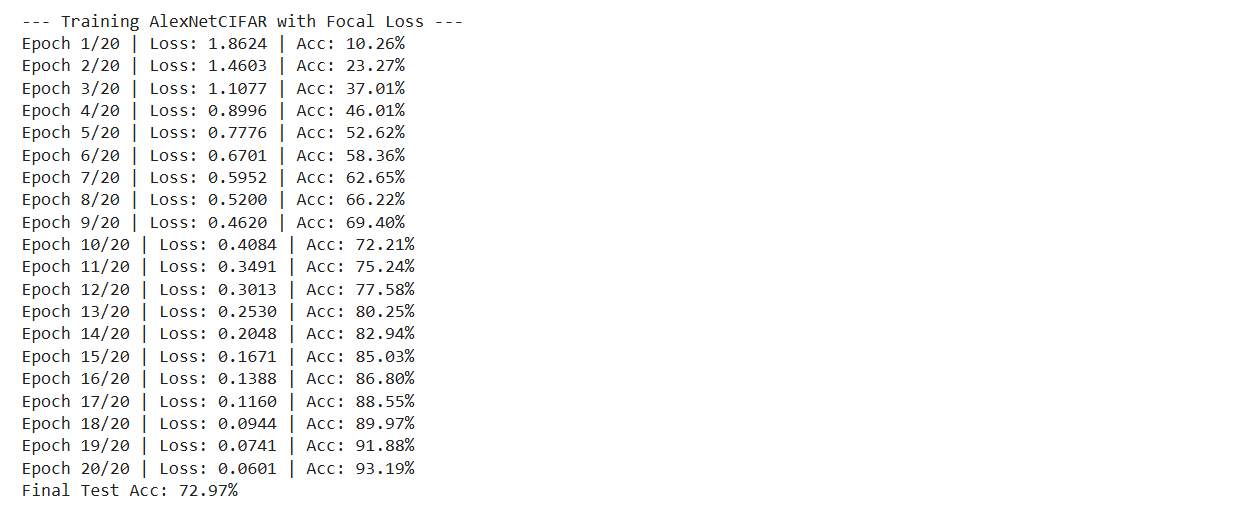

ResNet + Adam + ArcFace (15 epochs)

In [ ]:
model_arc = ResNet50()

criterion = ArcFaceLoss()

optimizer = torch.optim.Adam(
    model_arc.parameters(),
    lr=0.001
)

train_model(model_arc, trainloader, criterion, optimizer, epochs=15)
test_model(model_arc, testloader)

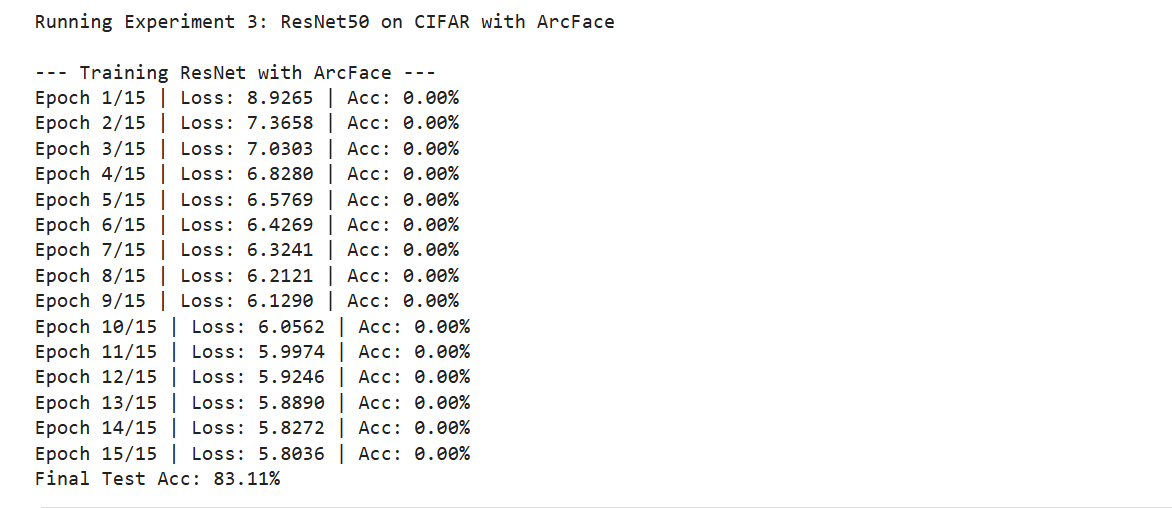

Part-3

In [ ]:
def extract_features(model, loader, device, max_samples=2000):

    model.eval()

    features = []
    labels_list = []

    with torch.no_grad():
        for images, labels in loader:

            images = images.to(device)

            # 🔥 remove classifier layer
            x = model.features(images) if hasattr(model, 'features') else model.stem(images)

            x = torch.nn.functional.adaptive_avg_pool2d(x, (1,1))
            x = torch.flatten(x, 1)

            features.append(x.cpu())
            labels_list.append(labels)

            if len(torch.cat(features)) >= max_samples:
                break

    return torch.cat(features)[:max_samples], torch.cat(labels_list)[:max_samples]


In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def plot_tsne(features, labels, title):

    tsne = TSNE(n_components=2, random_state=42)
    reduced = tsne.fit_transform(features)

    plt.figure(figsize=(8, 6))

    scatter = plt.scatter(
        reduced[:, 0],
        reduced[:, 1],
        c=labels,
        cmap='tab10',
        s=5
    )

    plt.colorbar(scatter)
    plt.title(title)
    plt.show()


bce model

In [ ]:
features, labels = extract_features(model_focalFace, testloader, device)

plot_tsne(features, labels,
          "t-SNE: AlexNet + Focal Loss on CIFAR-10")


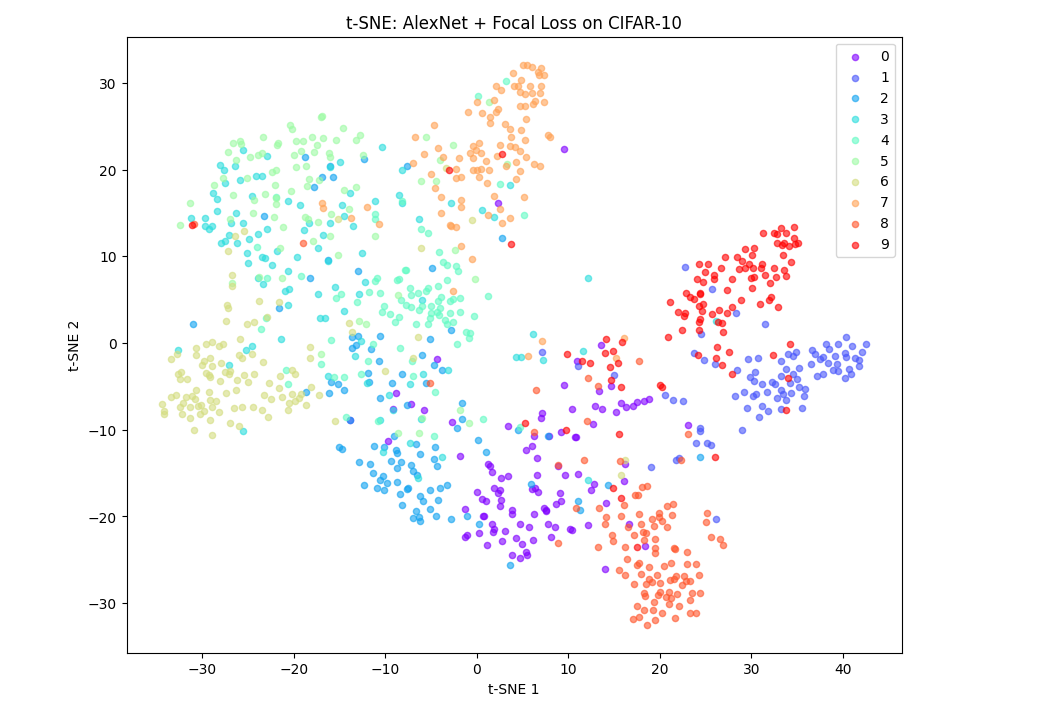

ArcFace Model

In [ ]:
features, labels = extract_features(model_arcface, testloader, device)

plot_tsne(features, labels,
          "t-SNE: ResNet + ArcFace on CIFAR-10")

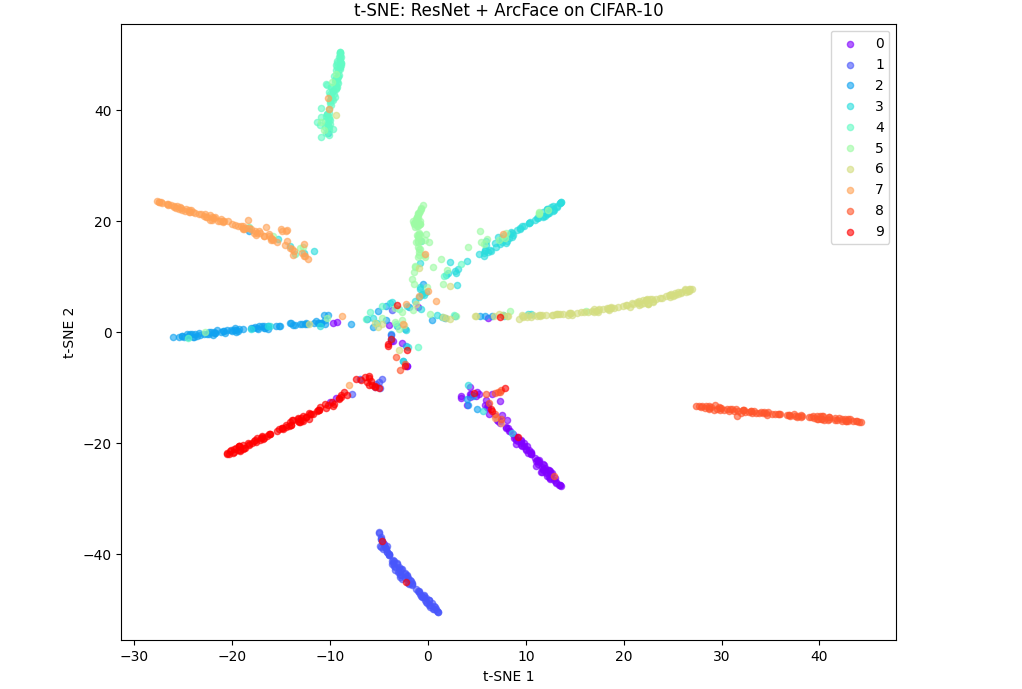